In [1]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [23]:

# Cargar el dataset principal de solicitudes de adelanto en efectivo
cash_request = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/extract - cash request - data analyst.csv')


In [24]:
cr = cash_request.copy()


In [25]:
# Filtrar columnas relevantes para el análisis
cr = cr[["amount", "created_at", "user_id", "deleted_account_id", "transfer_type"]]
cr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amount              23970 non-null  float64
 1   created_at          23970 non-null  object 
 2   user_id             21867 non-null  float64
 3   deleted_account_id  2104 non-null   float64
 4   transfer_type       23970 non-null  object 
dtypes: float64(3), object(2)
memory usage: 936.5+ KB


In [26]:
# Rellenar valores nulos en 'user_id' usando 'deleted_account_id'
# (clientes transferidos de cuentas eliminadas)
cr.fillna({"user_id": cr["deleted_account_id"]}, inplace=True)


In [27]:
# Eliminar la columna 'deleted_account_id' ya que no es necesaria después de la imputación
cr.drop(columns=["deleted_account_id"], inplace=True)
cr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   amount         23970 non-null  float64
 1   created_at     23970 non-null  object 
 2   user_id        23970 non-null  float64
 3   transfer_type  23970 non-null  object 
dtypes: float64(2), object(2)
memory usage: 749.2+ KB


In [28]:
# Convertir 'created_at' a tipo datetime para manipulación de fechas
cr['created_at'] = pd.to_datetime(cr['created_at'])
cr.head()


,amount,created_at,user_id,transfer_type
0,100.0,2019-12-10 19:05:21.596873+00:00,804.0,regular
1,100.0,2019-12-10 19:50:12.347780+00:00,231.0,regular
2,100.0,2019-12-10 19:13:35.825460+00:00,191.0,regular
3,99.0,2019-12-10 19:16:10.880172+00:00,761.0,regular
4,100.0,2020-05-06 09:59:38.877376+00:00,7686.0,regular


In [29]:
# Convertir la columna 'created_at' a una fecha sin zona horaria
cr['created_at'] = cr['created_at'].dt.tz_localize(None)
cr.head()


,amount,created_at,user_id,transfer_type
0,100.0,2019-12-10 19:05:21.596873,804.0,regular
1,100.0,2019-12-10 19:50:12.347780,231.0,regular
2,100.0,2019-12-10 19:13:35.825460,191.0,regular
3,99.0,2019-12-10 19:16:10.880172,761.0,regular
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular


In [30]:
# Crear columna 'Mes' indicando el mes de cada solicitud
cr['Semana'] = cr['created_at'].dt.to_period('W')
cr.head()


,amount,created_at,user_id,transfer_type,Semana
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12-09/2019-12-15
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12-09/2019-12-15
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12-09/2019-12-15
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12-09/2019-12-15
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05-04/2020-05-10


In [31]:
# Crear columna 'Cohorte' que indica el mes de la primera solicitud de cada cliente
cr['Cohorte'] = cr.groupby('user_id')['created_at'].transform('min').dt.to_period('W')
cr.head(10)


,amount,created_at,user_id,transfer_type,Semana,Cohorte
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05-04/2020-05-10,2020-05-04/2020-05-10
5,100.0,2020-05-23 20:58:55.129432,9489.0,regular,2020-05-18/2020-05-24,2020-05-18/2020-05-24
6,100.0,2020-06-16 17:07:38.452652,14631.0,regular,2020-06-15/2020-06-21,2020-06-15/2020-06-21
7,100.0,2020-02-10 01:11:53.808270,309.0,regular,2020-02-10/2020-02-16,2020-01-27/2020-02-02
8,100.0,2020-06-28 12:06:33.712840,2499.0,regular,2020-06-22/2020-06-28,2020-06-22/2020-06-28
9,90.0,2019-12-10 19:51:23.911206,897.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15


In [32]:
# Agregar columnas de temporalidad

# Semana y mes de la solicitud
cr['Semana_Mes'] = cr['created_at'].dt.strftime('%U_%B') + '_' + cr['Semana'].dt.strftime('%Y')

# Día y semana de la solicitud
cr['Dia_Semana'] = cr['created_at'].dt.strftime('%A') + '_' + cr['Semana_Mes']

# Hora y día de la solicitud
cr['Hora_Dia'] = cr['created_at'].dt.hour.astype(str) + '_' + cr['Dia_Semana']

cr.head()


,amount,created_at,user_id,transfer_type,Semana,Cohorte,Semana_Mes,Dia_Semana,Hora_Dia
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05-04/2020-05-10,2020-05-04/2020-05-10,18_May_2020,Wednesday_18_May_2020,9_Wednesday_18_May_2020


In [33]:
# Calcular la cantidad de adelanto de efectivo por cohorte y mes
cohort_revenue = cr.groupby(['Cohorte', 'Semana'])['amount'].sum().reset_index()

# Crear tabla pivote con Cohorte como índice y Mes como columnas
cohort_revenue = cohort_revenue.pivot(index='Cohorte', columns='Semana', values='amount')

cohort_revenue


Semana,2019-11-18/2019-11-24,2019-12-09/2019-12-15,2019-12-16/2019-12-22,2019-12-23/2019-12-29,2019-12-30/2020-01-05,2020-01-06/2020-01-12,2020-01-13/2020-01-19,2020-01-20/2020-01-26,2020-01-27/2020-02-02,2020-02-03/2020-02-09,...,2020-08-24/2020-08-30,2020-08-31/2020-09-06,2020-09-07/2020-09-13,2020-09-14/2020-09-20,2020-09-21/2020-09-27,2020-09-28/2020-10-04,2020-10-05/2020-10-11,2020-10-12/2020-10-18,2020-10-19/2020-10-25,2020-10-26/2020-11-01
Cohorte,,,,,,,,,,,,,,,,,,,,,
2019-11-18/2019-11-24,1.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,1.0
2019-12-09/2019-12-15,NaN,10026.0,770.0,810.0,1050.0,1320.0,1515.0,460.0,870.0,650.0,...,150.0,650.0,1000.0,450.0,400.0,100.0,450.0,1130.0,300.0,350.0
2019-12-16/2019-12-22,NaN,NaN,10321.0,550.0,1190.0,1250.0,700.0,860.0,448.0,801.0,...,300.0,600.0,900.0,210.0,NaN,200.0,950.0,650.0,275.0,550.0
2019-12-23/2019-12-29,NaN,NaN,NaN,3180.0,100.0,200.0,300.0,200.0,300.0,400.0,...,NaN,350.0,NaN,300.0,50.0,100.0,500.0,650.0,150.0,150.0
2019-12-30/2020-01-05,NaN,NaN,NaN,NaN,1300.0,200.0,NaN,100.0,100.0,200.0,...,NaN,100.0,300.0,50.0,NaN,100.0,250.0,NaN,NaN,NaN
2020-01-06/2020-01-12,NaN,NaN,NaN,NaN,NaN,2900.0,100.0,200.0,498.0,300.0,...,200.0,NaN,200.0,100.0,NaN,NaN,100.0,100.0,100.0,250.0
2020-01-13/2020-01-19,NaN,NaN,NaN,NaN,NaN,NaN,1050.0,NaN,80.0,180.0,...,100.0,50.0,NaN,NaN,100.0,NaN,100.0,100.0,NaN,200.0
2020-01-20/2020-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1200.0,300.0,200.0,...,NaN,260.0,60.0,NaN,50.0,100.0,NaN,150.0,NaN,100.0
2020-01-27/2020-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5406.0,600.0,...,NaN,400.0,200.0,300.0,350.0,100.0,200.0,450.0,200.0,200.0


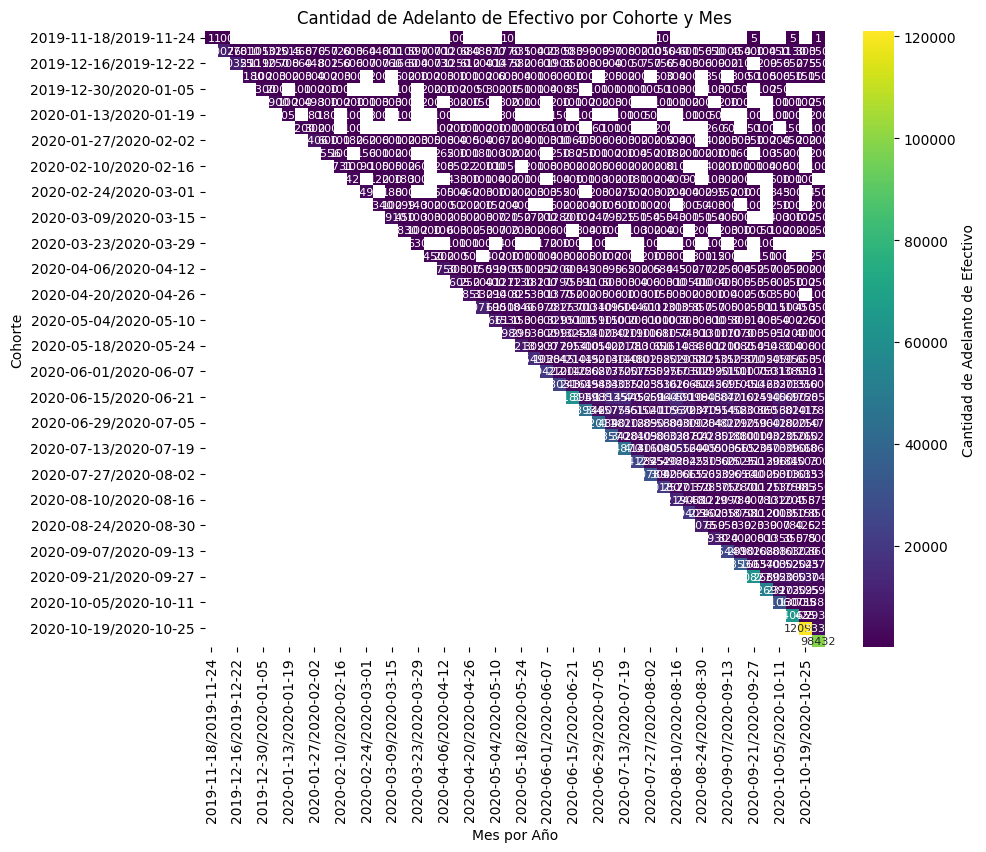

In [34]:
# Graficar la cantidad de adelanto de efectivo por cohorte y mes
plt.figure(figsize=(10, 8))
plt.title('Cantidad de Adelanto de Efectivo por Cohorte y Mes')

sns.heatmap(
    data=cohort_revenue,
    annot=True,
    fmt='.0f',
    cmap='viridis',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Cantidad de Adelanto de Efectivo'}
)

plt.xlabel('Mes por Año')
plt.ylabel('Cohorte')
plt.show()



📊 Evaluación del Modelo:
RMSE Interpolación: 1362.782, RMSE Extrapolación: 404.276
R² Interpolación: -10.672, R² Extrapolación: -11.329

🔍 Valores negativos en extrapolación:
[]


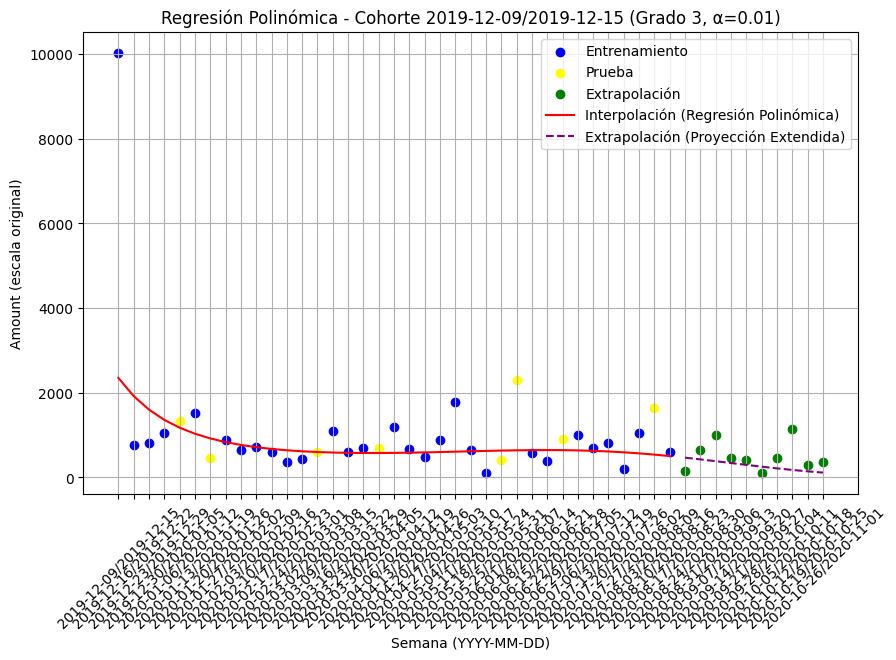

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Asegurar que los índices y columnas sean strings
cohort_revenue.index = cohort_revenue.index.astype(str)
cohort_revenue.columns = cohort_revenue.columns.astype(str)

# 🔹 2️⃣ Seleccionar la cohorte específica
semana_objetivo = '2019-12-09/2019-12-15'
if semana_objetivo in cohort_revenue.index:
    cohort_2019_12_09 = cohort_revenue.loc[semana_objetivo].dropna()
else:
    print(f"⚠️ La semana {semana_objetivo} no se encuentra en cohort_revenue.index")
    print("Índices disponibles:", list(cohort_revenue.index))
    raise KeyError(f"La semana {semana_objetivo} no está en los datos.")

# 🔹 3️⃣ Convertir semanas a variable numérica
X = np.arange(len(cohort_2019_12_09)).reshape(-1, 1)  # Índices numéricos
y = np.log1p(cohort_2019_12_09.values)  # Aplicar transformación logarítmica

# 🔹 4️⃣ Dividir datos en entrenamiento (80%) y prueba (20%)
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 🔹 5️⃣ Dividir el 80% de interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 🔹 6️⃣ Aplicar regresión polinómica con Ridge
degree = 3  # Ajustar grado si es necesario
alpha = 0.01  # Regularización

poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# 🔹 7️⃣ Predicciones
y_interp_pred = model.predict(X_interp_poly)
y_extrap_pred = model.predict(X_extrap_poly)

# 🔹 8️⃣ Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 9️⃣ Evaluación del modelo
rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

print(f"\n📊 Evaluación del Modelo:")
print(f"RMSE Interpolación: {rmse_interp:.3f}, RMSE Extrapolación: {rmse_extrap:.3f}")
print(f"R² Interpolación: {r2_interp:.3f}, R² Extrapolación: {r2_extrap:.3f}")

# 🔍 Verificar valores negativos en extrapolación
print("\n🔍 Valores negativos en extrapolación:")
print(y_extrap_pred[y_extrap_pred < 0])

# 🔹 🔄 Graficar resultados
plt.figure(figsize=(10, 6))

# Datos originales transformados de vuelta
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación (Regresión Polinómica)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación (Proyección Extendida)')

# Configuración de la gráfica
plt.xticks(X.flatten(), cohort_2019_12_09.index, rotation=45)
plt.xlabel("Semana (YYYY-MM-DD)")
plt.ylabel("Amount (escala original)")
plt.title(f"Regresión Polinómica - Cohorte {semana_objetivo} (Grado {degree}, α={alpha})")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


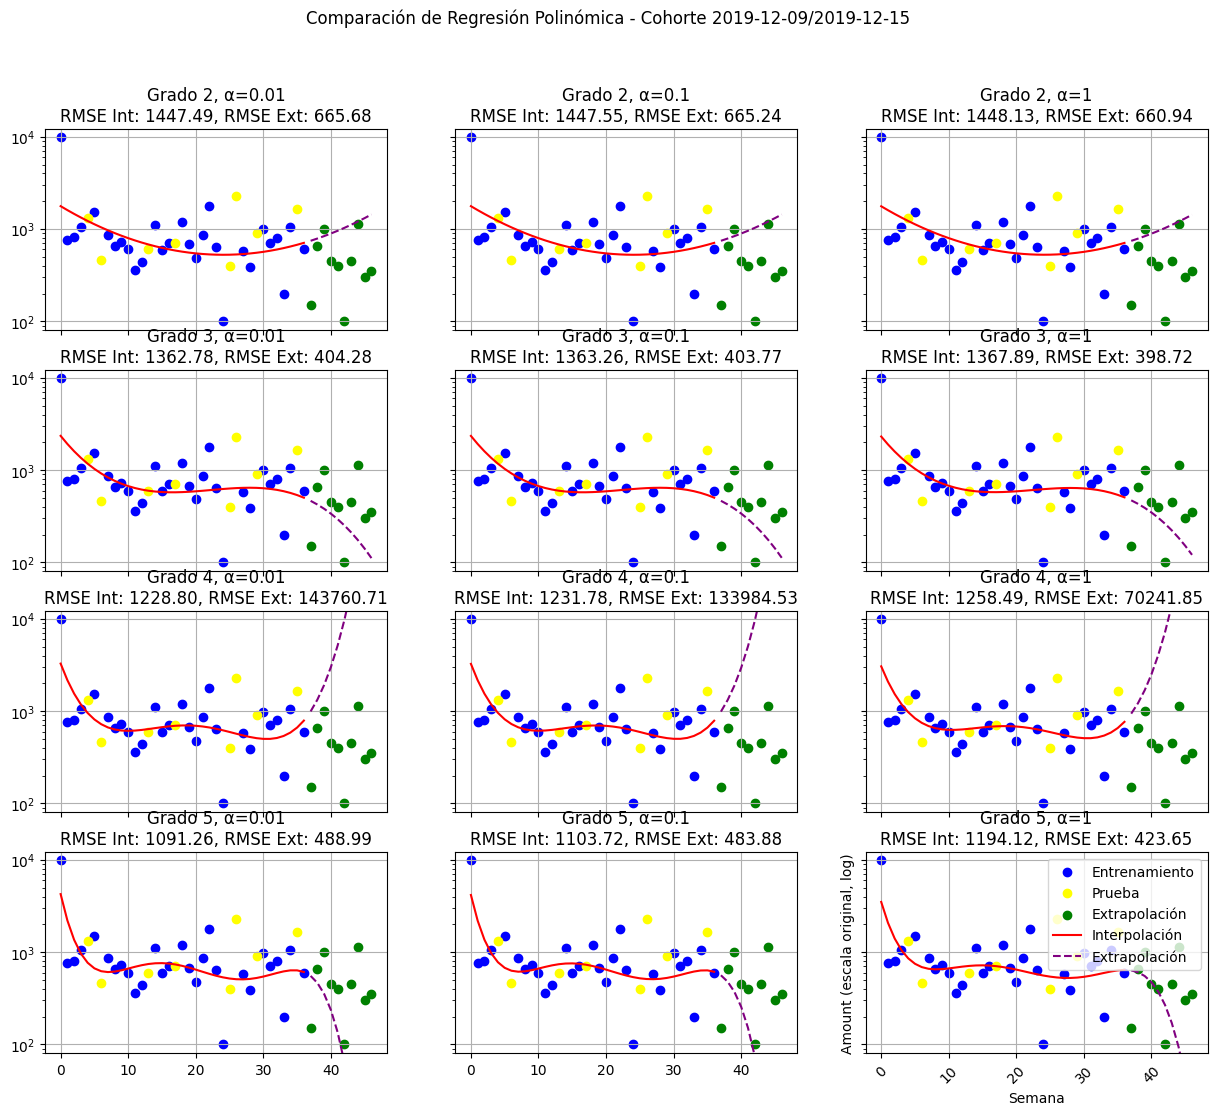

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Asegurar que los índices y columnas sean strings
cohort_revenue.index = cohort_revenue.index.astype(str)
cohort_revenue.columns = cohort_revenue.columns.astype(str)

# 🔹 2️⃣ Seleccionar la cohorte específica
semana_objetivo = '2019-12-09/2019-12-15'
if semana_objetivo in cohort_revenue.index:
    cohort_2019_12_09 = cohort_revenue.loc[semana_objetivo].dropna()
else:
    print(f"⚠️ La semana {semana_objetivo} no se encuentra en cohort_revenue.index")
    print("Índices disponibles:", list(cohort_revenue.index))
    raise KeyError(f"La semana {semana_objetivo} no está en los datos.")

# 🔹 3️⃣ Convertir semanas a variable numérica
X = np.arange(len(cohort_2019_12_09)).reshape(-1, 1)  # Índices numéricos
y = np.log1p(cohort_2019_12_09.values)  # Aplicar transformación logarítmica

# 🔹 4️⃣ Dividir datos en entrenamiento (80%) y prueba (20%)
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 🔹 5️⃣ Dividir el 80% de interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 🔹 6️⃣ Probar múltiples valores de `degree` y `alpha`
degrees = [2, 3, 4, 5]
alphas = [0.01, 0.1, 1]

fig, axes = plt.subplots(len(degrees), len(alphas), figsize=(15, 12), sharex=True, sharey=True)

# Determinar los límites del eje Y
y_min, y_max = np.expm1(y).min(), np.expm1(y).max()

for i, degree in enumerate(degrees):
    for j, alpha in enumerate(alphas):
        poly = PolynomialFeatures(degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        X_interp_poly = poly.transform(X_interp)
        X_extrap_poly = poly.transform(X_extrap)

        model = Ridge(alpha=alpha)
        model.fit(X_train_poly, y_train)

        # Predicciones
        y_interp_pred = model.predict(X_interp_poly)
        y_extrap_pred = model.predict(X_extrap_poly)

        # Volver a la escala original
        y_interp_pred = np.expm1(y_interp_pred)
        y_extrap_pred = np.expm1(y_extrap_pred)
        y_train_orig = np.expm1(y_train)
        y_test_orig = np.expm1(y_test)
        y_extrap_orig = np.expm1(y_extrap)

        # Evaluación del modelo
        rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
        rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
        r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
        r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

        # Graficar resultados
        ax = axes[i, j]
        ax.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
        ax.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
        ax.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

        # Líneas de tendencia
        ax.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación')
        ax.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación')

        # 🔹 Ajustar escala logarítmica en el eje Y
        ax.set_yscale('log')
        ax.set_ylim(y_min * 0.8, y_max * 1.2)

        ax.set_title(f"Grado {degree}, α={alpha}\nRMSE Int: {rmse_interp:.2f}, RMSE Ext: {rmse_extrap:.2f}")
        ax.grid(True)

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original, log)")
plt.suptitle(f"Comparación de Regresión Polinómica - Cohorte {semana_objetivo}")
plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor visibilidad
plt.legend()
plt.show()
